# STOXX Europe 600 historical membership (1999-2025)

This notebook builds a yearly membership matrix for the STOXX Europe 600 (RIC: `.STOXX`) using **Index Joiners/Leavers** from LSEG Data Library.

**Outputs**
- `intermediate/stoxx600_membership_matrix_2000_2025.parquet`
- `tables/stoxx600_membership_matrix_2000_2025.xlsx`

The final table has **one row per RIC**, yearly dummies (0/1), plus **CompanyName**, **CountryHQ**, and `years_in_index`.


In [2]:
# --- Imports & configuration ---
from pathlib import Path
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lseg.data as ld

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

In [3]:
# --- Storage structure for intermediate and final output ---
BASE_DIR = Path(
    "/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data"
)
BASE_DIR.mkdir(parents=True, exist_ok=True)

(TABLE_DIR := BASE_DIR / "tables").mkdir(exist_ok=True)
(DATA_DIR  := BASE_DIR / "intermediate").mkdir(exist_ok=True)

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

def save_xlsx(df: pd.DataFrame, name: str):
    path = TABLE_DIR / f"{name}.xlsx"
    df.to_excel(path, index=False)
    print(f"Saved: {path}")


In [4]:
# --- Parameters ---
INDEX_RIC = ".STOXX"  # STOXX Europe 600

# We start from an initial snapshot at 1999-12-31 so that year 1999 is correct.
INIT_DATE = "19991231"

# Pull joiners/leavers from 1999 onward (covers 1999-2025 membership changes)
JL_START = "19990101"
JL_END   = "20251231"

YEARS = list(range(1999, 2026))
YEAR_ENDS = pd.to_datetime([f"{y}-12-31" for y in YEARS])


In [5]:
# --- Helpers ---

def chunked(lst, n=200):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def _rename_first_match(df: pd.DataFrame, candidates, new_name: str) -> pd.DataFrame:
    for c in candidates:
        if c in df.columns:
            return df.rename(columns={c: new_name})
    return df

def _require_cols(df: pd.DataFrame, cols, context: str = ""):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns {missing} {('in '+context) if context else ''}. "
            f"Got columns: {list(df.columns)}"
        )


## 1) Pull initial constituents and joiners/leavers

We reconstruct membership by:
1. Taking an **initial constituent snapshot** at `INIT_DATE`
2. Pulling **joiners/leavers** between `JL_START` and `JL_END`
3. Applying changes chronologically and recording membership at each year-end

> Note: Field names can vary slightly by account/entitlements. This notebook uses the field name that worked in your environment.


In [6]:
# --- 1A) Initial constituents (snapshot) ---
ld.open_session()

initial = ld.get_data(
    universe=[f"0#{INDEX_RIC}({INIT_DATE})"],
    fields=["TR.RIC"],
).copy()

ld.close_session()

initial = _rename_first_match(initial, ["RIC", "Constituent RIC"], "ConstituentRIC")
_require_cols(initial, ["ConstituentRIC"], context="initial snapshot")

initial_rics = set(initial["ConstituentRIC"].dropna().unique())
print("Initial constituents:", len(initial_rics))
initial.head()


Initial constituents: 600


,Instrument,ConstituentRIC
0,DHER.DE,DHER.DE
1,ORSTED.CO,ORSTED.CO
2,EVKn.DE,EVKn.DE
3,FREG.DE,FREG.DE
4,SECUb.ST,SECUb.ST


In [7]:
# --- 1B) Joiners/Leavers (Index JL) ---
# IMPORTANT: The change field is required to know whether a record is JOINER or LEAVER.

FIELDS_JL = [
    "TR.IndexJLConstituentChangeDate",
    "TR.IndexJLConstituentRIC",
    "TR.IndexJLConstituentName",
    "TR.IndexJLConstituentituentChange",  # LSEG example uses this exact spelling
]

ld.open_session()

jl = ld.get_data(
    universe=[INDEX_RIC],
    fields=FIELDS_JL,
    parameters={"SDate": JL_START, "EDate": JL_END, "IC": "B"},
).copy()

ld.close_session()

# Normalize column names (LSEG output labels can differ)
jl = _rename_first_match(jl, ["Date", "Index JL Constituent Change Date"], "ChangeDate")
jl = _rename_first_match(jl, ["Constituent RIC", "Index JL Constituent RIC"], "ConstituentRIC")
jl = _rename_first_match(jl, ["Constituent Name", "Index JL Constituent Name"], "ConstituentName")

# Change flag label varies; handle common variants
jl = _rename_first_match(jl, [
    "Constituentituent Change",
    "Constituent Change",
    "Index JL Constituent Change",
], "Change")

_require_cols(jl, ["ChangeDate", "ConstituentRIC"], context="joiners/leavers")
if "Change" not in jl.columns:
    raise ValueError(
        "The joiner/leaver pull does not include a Change flag column. "
        "Re-run with the correct change field for your account."
    )

jl["ChangeDate"] = pd.to_datetime(jl["ChangeDate"])
jl["Change"] = jl["Change"].astype(str)

print("JL rows:", len(jl))
jl.head()


JL rows: 3407


,Instrument,ChangeDate,ConstituentRIC,ConstituentName,Change
0,.STOXX,1999-02-04,BTR.L^B99,Invensys Intl UK,Leaver
1,.STOXX,1999-02-08,DGXG.DE^I06,Evonik Operation,Joiner
2,.STOXX,1999-02-08,DGXG.F^I06,Evonik Operation,Leaver
3,.STOXX,1999-03-22,TUI1n.DE,TUI,Joiner
4,.STOXX,1999-03-22,PANr.AT^G04,Vodafone Panafon,Joiner


## 2) Reconstruct yearly membership (year-end snapshots)

We apply joiners/leavers in chronological order up to each year-end date. Re-entries are handled naturally: a RIC can be removed and later added again.


In [8]:
# --- 2) Apply changes and record year-end membership ---

jl2 = jl[["ChangeDate", "ConstituentRIC", "Change"]].dropna().sort_values("ChangeDate").reset_index(drop=True)

current = set(copy.deepcopy(list(initial_rics)))
snapshots = []

j = 0
for yend in YEAR_ENDS:
    while j < len(jl2) and jl2.loc[j, "ChangeDate"] <= yend:
        ric = jl2.loc[j, "ConstituentRIC"]
        chg = str(jl2.loc[j, "Change"]).strip().lower()

        # handle typical encodings
        if "join" in chg or chg in {"j", "in", "add", "added"}:
            current.add(ric)
        elif "leav" in chg or chg in {"l", "out", "del", "deleted", "remove", "removed"}:
            current.discard(ric)

        j += 1

    snapshots.append(pd.DataFrame({
        "ConstituentRIC": list(current),
        "Year": yend.year,
    }))

stoxx_hist = pd.concat(snapshots, ignore_index=True)

print("Years:", stoxx_hist["Year"].min(), "-", stoxx_hist["Year"].max())
print("Avg constituents/year:", stoxx_hist.groupby("Year")["ConstituentRIC"].nunique().mean())
stoxx_hist.head()


Years: 1999 - 2025
Avg constituents/year: 725.6666666666666


,ConstituentRIC,Year
0,GMAB.CO,1999
1,NESN.S,1999
2,ADML.L,1999
3,HSBA.L,1999
4,BGEO.L,1999


## 3) Membership matrix (wide) + years_in_index

We pivot the reconstructed history into a wide **RIC × Year** matrix with dummies and compute `years_in_index`.


In [9]:
# --- 3) Build membership matrix ---

membership = (
    pd.crosstab(stoxx_hist["ConstituentRIC"], stoxx_hist["Year"])
      .reindex(columns=YEARS, fill_value=0)
      .clip(upper=1)
      .astype("int8")
      .reset_index()
)

membership["years_in_index"] = membership[YEARS].sum(axis=1).astype(int)

membership[["ConstituentRIC", "years_in_index"]].describe()


Year,years_in_index
count,1356.000000
mean,14.449115
std,10.875325
min,1.000000
25%,3.000000
50%,12.000000
75%,27.000000
max,27.000000


## 4) Enrich with CompanyName, CountryHQ, and TRBC sectors

We pull static firm metadata for all unique RICs that appear in the reconstructed sample.


In [10]:
# --- 4A) Pull metadata for all unique RICs ---
rics = membership["ConstituentRIC"].dropna().unique().tolist()
print("Unique RICs in sample:", len(rics))

ld.open_session()

meta_parts = []
for rchunk in chunked(rics, n=200):
    df = ld.get_data(
        universe=rchunk,
        fields=[
            "TR.CommonName",
            "TR.HeadquartersCountry",
            "TR.TRBCEconomicSector",
            "TR.TRBCBusinessSector",
        ],
    ).copy()

    df = _rename_first_match(df, ["Instrument", "RIC"], "ConstituentRIC")

    # Company name
    df = _rename_first_match(df, ["Company Common Name", "Common Name"], "CompanyName")

    # HQ country
    df = _rename_first_match(df, ["Country of Headquarters", "Headquarters Country"], "CountryHQ")

    # TRBC sectors (labels can vary by entitlement/output settings)
    df = _rename_first_match(
        df,
        ["TRBC Economic Sector", "Economic Sector", "TRBC Economic Sector Name"],
        "EconomicSector",
    )
    df = _rename_first_match(
        df,
        ["TRBC Business Sector", "Business Sector", "TRBC Business Sector Name"],
        "BusinessSector",
    )

    # Ensure expected columns exist even if LSEG does not return a field for this chunk
    for col in ["ConstituentRIC", "CompanyName", "CountryHQ", "EconomicSector", "BusinessSector"]:
        if col not in df.columns:
            df[col] = pd.NA

    meta_parts.append(
        df[[
            "ConstituentRIC",
            "CompanyName",
            "CountryHQ",
            "EconomicSector",
            "BusinessSector",
        ]]
    )

ld.close_session()

meta = pd.concat(meta_parts, ignore_index=True).drop_duplicates(subset=["ConstituentRIC"])

print("Missing CompanyName:", meta["CompanyName"].isna().mean())
print("Missing CountryHQ:", meta["CountryHQ"].isna().mean())
print("Missing EconomicSector:", meta["EconomicSector"].isna().mean())
print("Missing BusinessSector:", meta["BusinessSector"].isna().mean())
meta.head()


Unique RICs in sample: 1356
Missing CompanyName: 0.0
Missing CountryHQ: 0.0
Missing EconomicSector: 0.0
Missing BusinessSector: 0.0


,ConstituentRIC,CompanyName,CountryHQ,EconomicSector,BusinessSector
0,1COVG.DE^L25,Covestro AG,Germany,Basic Materials,Chemicals
1,1U1.DE,1&1 AG,Germany,Technology,Telecommunications Services
2,A2.MI,A2A SpA,Italy,Utilities,Utilities
3,A3M.MC,Atresmedia Corporacion de Medios de Comunicaci...,Spain,Consumer Cyclicals,Cyclical Consumer Services
4,AAAA.L^C21,AA Ltd,United Kingdom,Consumer Non-Cyclicals,Personal & Household Products & Services


In [11]:
# --- 4B) Merge metadata into final table ---

membership_final = membership.merge(meta, on="ConstituentRIC", how="left")

# column order
membership_final = membership_final[
    [
        "ConstituentRIC",
        "CompanyName",
        "CountryHQ",
        "EconomicSector",
        "BusinessSector",
        "years_in_index",
    ] + YEARS
]

membership_final.head(10)


,ConstituentRIC,CompanyName,CountryHQ,EconomicSector,BusinessSector,years_in_index,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,1COVG.DE^L25,Covestro AG,Germany,Basic Materials,Chemicals,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0
1,1U1.DE,1&1 AG,Germany,Technology,Telecommunications Services,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0
2,A2.MI,A2A SpA,Italy,Utilities,Utilities,23,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1
3,A3M.MC,Atresmedia Corporacion de Medios de Comunicaci...,Spain,Consumer Cyclicals,Cyclical Consumer Services,3,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,AAAA.L^C21,AA Ltd,United Kingdom,Consumer Non-Cyclicals,Personal & Household Products & Services,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0
5,AAF.L,Airtel Africa PLC,United Kingdom,Technology,Telecommunications Services,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,AAK.ST,AAK AB (publ),Sweden,Consumer Non-Cyclicals,Food & Beverages,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
7,AAL.L,Anglo American PLC,United Kingdom,Basic Materials,Mineral Resources,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
8,AALB.AS,Aalberts NV,Netherlands,Industrials,Industrial Goods,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
9,ABBN.S,Abb Ltd,Switzerland,Industrials,Industrial Goods,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


## 5) Diagnostics


In [12]:
# --- Diagnostics ---

# 1) members per year
members_per_year = stoxx_hist.groupby("Year")["ConstituentRIC"].nunique()
print(members_per_year.head())
print(members_per_year.describe())

# 2) How often do we see re-entries (0->1 transitions after first entry)?
M = membership_final.set_index("ConstituentRIC")[YEARS]
diff = M.diff(axis=1).fillna(0)
reentries = (diff == 1).sum(axis=1) - 1
reentries = reentries.clip(lower=0)
print("RICs with re-entries:", int((reentries > 0).sum()))
reentries.sort_values(ascending=False).head(10)


Year
1999    716
2000    770
2001    778
2002    778
2003    789
Name: ConstituentRIC, dtype: int64
count     27.000000
mean     725.666667
std       59.325698
min      600.000000
25%      689.000000
50%      753.000000
75%      774.000000
max      789.000000
Name: ConstituentRIC, dtype: float64
RICs with re-entries: 139


ConstituentRIC
TCAPI.L       3
GXIG.DE       3
CPIE.VI       2
JLT.L^D19     2
SMWH.L        2
DLAR.L^G25    2
BION.S        2
BILL.ST       2
OUT1V.HE      2
BCP.LS        2
dtype: int64

## 6) Nur RICs mit EURO HQ

In [13]:
# Euro area countries as of 1 Jan 2026 (21)
EURO_HQ = {
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Estonia",
    "Finland", "France", "Germany", "Greece", "Ireland", "Italy",
    "Latvia", "Lithuania", "Luxembourg", "Malta", "Netherlands",
    "Portugal", "Slovakia", "Slovenia", "Spain"
}

# if your table is called membership_final (from the cleaned notebook):
df = membership_final.copy()

# robust normalization (handles "Germany" vs "GERMANY", extra spaces, etc.)
df["CountryHQ_clean"] = (
    df["CountryHQ"]
      .astype("string")
      .str.strip()
)

# filter
membership_eurohq = df[df["CountryHQ_clean"].isin(EURO_HQ)].copy()

# optional: drop helper column
membership_eurohq = membership_eurohq.drop(columns=["CountryHQ_clean"], errors="ignore")

print("Rows (RICs):", len(membership_eurohq))
membership_eurohq.head(10)

Rows (RICs): 667


,ConstituentRIC,CompanyName,CountryHQ,EconomicSector,BusinessSector,years_in_index,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,1COVG.DE^L25,Covestro AG,Germany,Basic Materials,Chemicals,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0
1,1U1.DE,1&1 AG,Germany,Technology,Telecommunications Services,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0
2,A2.MI,A2A SpA,Italy,Utilities,Utilities,23,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1
3,A3M.MC,Atresmedia Corporacion de Medios de Comunicaci...,Spain,Consumer Cyclicals,Cyclical Consumer Services,3,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,AALB.AS,Aalberts NV,Netherlands,Industrials,Industrial Goods,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
12,ABGek.MC^I22,Abengoa en Liquidacion SA,Spain,Industrials,Industrial & Commercial Services,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
13,ABI.BR,Anheuser-Busch Inbev SA,Belgium,Consumer Non-Cyclicals,Food & Beverages,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
14,ABNd.AS,ABN Amro Bank NV,Netherlands,Financials,Banking & Investment Services,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
16,ABVX.PA,Abivax SA,France,Healthcare,Pharmaceuticals & Medical Research,27,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
17,ACBr.AT,Alpha Bank SA,Greece,Financials,Banking & Investment Services,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


## 7) Save outputs

- Parquet to `intermediate/` (fast reload)
- Excel to `tables/` (final output for thesis / sharing)


In [14]:
# intermediate parquet
save_parquet(membership_eurohq, "stoxx600_membership_matrix_1999_2025_eurohq")

# final xlsx under tables/
xlsx_path = TABLE_DIR / "stoxx600_membership_matrix_1999_2025_eurohq.xlsx"
membership_eurohq.to_excel(xlsx_path, index=False)
print(f"Saved: {xlsx_path}")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/stoxx600_membership_matrix_1999_2025_eurohq.parquet
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/stoxx600_membership_matrix_1999_2025_eurohq.xlsx


## 8) Analysis of the Constituents


In [15]:
# --- Headquarters (CountryHQ) und Anzahl der Equities
df_hq_equities = (
    membership_eurohq
    .groupby("CountryHQ", as_index=False)
    .agg(
        NumEquities=("ConstituentRIC", "nunique")
    )
    .sort_values("NumEquities", ascending=False)
    .reset_index(drop=True)
)

# Mapping: Euro-Einführungsjahr nach Land (HQ)
euro_intro_year = {
    "Germany": 1999,
    "France": 1999,
    "Netherlands": 1999,
    "Italy": 1999,
    "Spain": 1999,
    "Finland": 1999,
    "Belgium": 1999,
    "Ireland": 1999,
    "Austria": 1999,
    "Portugal": 1999,
    "Luxembourg": 1999,
    "Greece": 2001,
    "Cyprus": 2008,
    "Malta": 2008
}

# Spalte hinzufügen
df_hq_equities["EuroIntroductionYear"] = (
    df_hq_equities["CountryHQ"]
    .map(euro_intro_year)
)

print(df_hq_equities)

share_1999 = (
    df_hq_equities
    .loc[df_hq_equities["EuroIntroductionYear"] == 1999, "NumEquities"]
    .sum()
    / df_hq_equities["NumEquities"].sum()
)

print(f"Share of Equities with Euro HQ since 1999: {share_1999:.2%}")

      CountryHQ  NumEquities  EuroIntroductionYear
0       Germany          154                  1999
1        France          130                  1999
2   Netherlands           84                  1999
3         Italy           79                  1999
4         Spain           63                  1999
5       Finland           35                  1999
6       Belgium           31                  1999
7       Ireland           23                  1999
8        Greece           22                  2001
9       Austria           18                  1999
10   Luxembourg           18                  1999
11     Portugal            7                  1999
12       Cyprus            2                  2008
13        Malta            1                  2008
Share of Equities with Euro HQ since 1999: 96.25%


### 8A) Verteilung nach Jahren im Index

Auswertung der Spalte `years_in_index` (Anzahl Jahre im STOXX 600 über 1999-2025).


In [16]:
# Basis: EURO-HQ Sample, falls vorhanden; sonst gesamtes Sample
base = membership_eurohq.copy() if 'membership_eurohq' in globals() else membership_final.copy()

dist_years = (
    base['years_in_index']
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis('years_in_index')
    .reset_index(name='NumEquities')
)
dist_years['Share'] = dist_years['NumEquities'] / dist_years['NumEquities'].sum()

print('Distribution of equities by years_in_index:')
print(dist_years)

print('\nSummary stats for years_in_index:')
print(base['years_in_index'].describe())


Distribution of equities by years_in_index:
    years_in_index  NumEquities     Share
0                1           79  0.118441
1                2           56  0.083958
2                3           30  0.044978
3                4           30  0.044978
4                5           29  0.043478
5                6           25  0.037481
6                7           14  0.020990
7                8           27  0.040480
8                9           14  0.020990
9               10           13  0.019490
10              11           12  0.017991
11              12           11  0.016492
12              13            8  0.011994
13              14            5  0.007496
14              15            2  0.002999
15              16            6  0.008996
16              17           10  0.014993
17              18            8  0.011994
18              19            6  0.008996
19              20           10  0.014993
20              21            3  0.004498
21              22            4 

### 8B) Aus welchen Sektoren kommen die Equities?

Sektorverteilung nach `TRBCEconomicSector` und `TRBCBusinessSector`.


In [17]:
base = membership_eurohq.copy() if 'membership_eurohq' in globals() else membership_final.copy()

econ_col = 'EconomicSector'
biz_col = 'BusinessSector'

if econ_col not in base.columns or biz_col not in base.columns:
    raise ValueError('Sector columns fehlen. Bitte Teil 4A/4B neu ausführen.')
sector_econ = (
    base.groupby(econ_col, dropna=False)['ConstituentRIC']
    .nunique()
    .sort_values(ascending=False)
    .rename('NumEquities')
    .reset_index()
)
sector_econ['Share'] = sector_econ['NumEquities'] / sector_econ['NumEquities'].sum()

sector_biz = (
    base.groupby(biz_col, dropna=False)['ConstituentRIC']
    .nunique()
    .sort_values(ascending=False)
    .rename('NumEquities')
    .reset_index()
)
sector_biz['Share'] = sector_biz['NumEquities'] / sector_biz['NumEquities'].sum()

print('Economic sector distribution (top 20):')
print(sector_econ.head(20))

print('\nBusiness sector distribution (top 20):')
print(sector_biz.head(20))


Economic sector distribution (top 20):
           EconomicSector  NumEquities     Share
0              Financials          119  0.178411
1             Industrials          118  0.176912
2      Consumer Cyclicals          101  0.151424
3              Technology           96  0.143928
4         Basic Materials           53  0.079460
5              Healthcare           44  0.065967
6  Consumer Non-Cyclicals           41  0.061469
7             Real Estate           37  0.055472
8               Utilities           30  0.044978
9                  Energy           28  0.041979

Business sector distribution (top 20):
                        BusinessSector  NumEquities     Share
0        Banking & Investment Services           85  0.127436
1                     Industrial Goods           51  0.076462
2     Industrial & Commercial Services           45  0.067466
3           Cyclical Consumer Services           43  0.064468
4          Telecommunications Services           39  0.058471
5         

### 8C) Graphische Darstellung

Visualisierung der Verteilungen fuer years_in_index sowie TRBC-Sektoren.


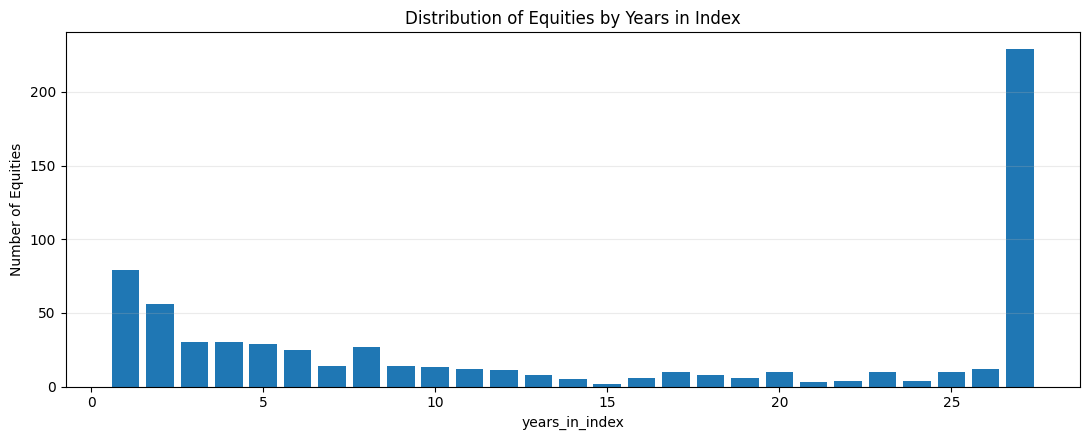

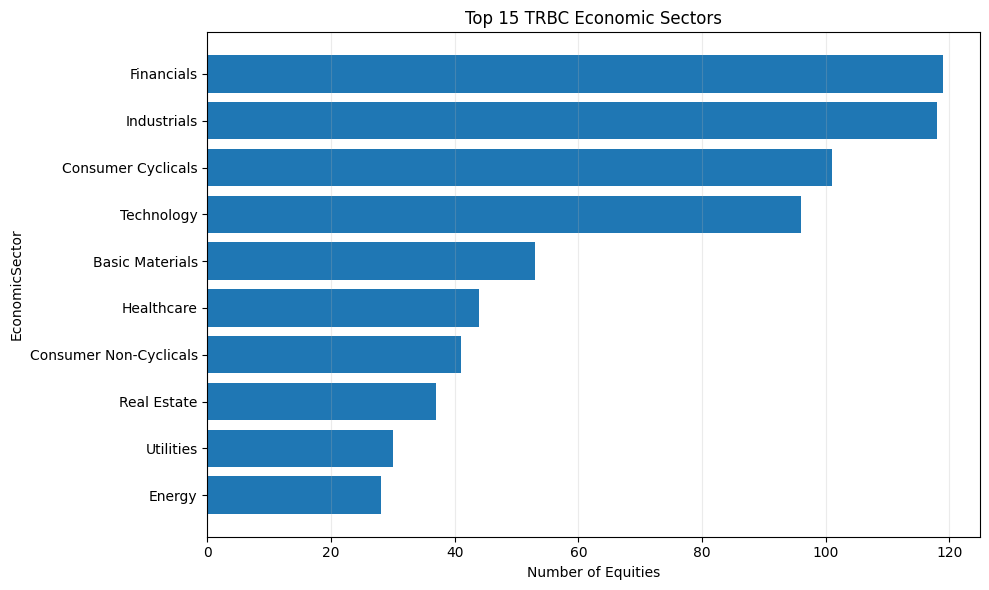

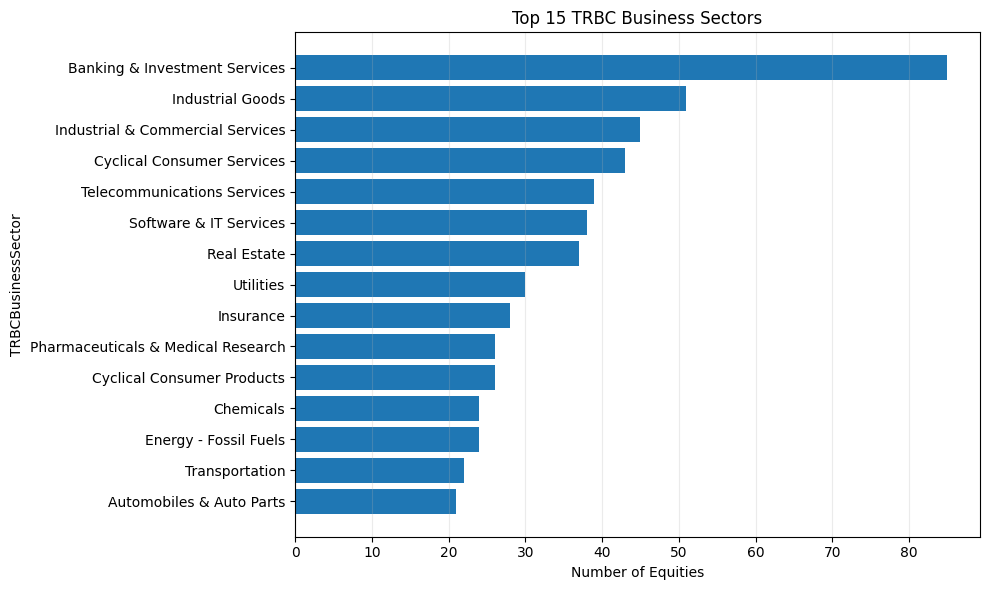

In [19]:
# --- Charts: years_in_index + sector distributions ---
base = membership_eurohq.copy() if 'membership_eurohq' in globals() else membership_final.copy()

# 1) Distribution by years_in_index
dist_years_plot = (
    base['years_in_index']
    .value_counts(dropna=False)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(dist_years_plot.index.astype(int), dist_years_plot.values)
ax.set_title('Distribution of Equities by Years in Index')
ax.set_xlabel('years_in_index')
ax.set_ylabel('Number of Equities')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Economic sector distribution (top 15)
if 'EconomicSector' in base.columns:
    econ_plot = (
        base.assign(EconomicSector=base['EconomicSector'].fillna('Unknown'))
        .groupby('EconomicSector')['ConstituentRIC']
        .nunique()
        .sort_values(ascending=False)
        .head(15)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(econ_plot.index, econ_plot.values)
    ax.set_title('Top 15 TRBC Economic Sectors')
    ax.set_xlabel('Number of Equities')
    ax.set_ylabel('EconomicSector')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('Column EconomicSector not found. Run section 4A/4B first.')

# 3) Business sector distribution (top 15)
if 'BusinessSector' in base.columns:
    biz_plot = (
        base.assign(BusinessSector=base['BusinessSector'].fillna('Unknown'))
        .groupby('BusinessSector')['ConstituentRIC']
        .nunique()
        .sort_values(ascending=False)
        .head(15)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(biz_plot.index, biz_plot.values)
    ax.set_title('Top 15 TRBC Business Sectors')
    ax.set_xlabel('Number of Equities')
    ax.set_ylabel('TRBCBusinessSector')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('Column TRBCBusinessSector not found. Run section 4A/4B first.')
